# WP5 · 07 — Spatial structure of miscalibration, and the decision-flip map (Figure F8)

**Work package:** WP5 extra / WP6 bridge · plan `docs/maup_sensitivity_and_spatial_cv_plan.md` §3.6
**Owner:** Geospatial Lead · **Country:** Sri Lanka · **Kernel:** `freight-eda` (needs `statsmodels`)

## Why this notebook exists, and why it was not blocked

Plan §3.6 asks where miscalibration and exposure-driven decision changes **concentrate in space**:
regress per-district calibration slope/intercept and per-district ΔNB on the geospatial modifiers
from the literature review, and draw the decision-flip / miscalibration map (**F8**, a named
deliverable in the plan's checklist).

The README recorded F8 as downstream of the §5.1-blocked refit. **It is not.** Apply the test that
has now recovered work four times — *does the blocker cover all of it?*

- Per-district **calibration slope and intercept** are a within-district fit of the outcome on
  `logit(p)`. That needs **predictions**, which we have frozen, not a design matrix.
- Per-district **ΔNB** is the net-benefit difference between the full and climate-free models on
  identical rows. Same: predictions only.
- Per-district **exposure-driven flip counts** were already computed in `wp5_05`.
- Every **modifier** on the plan's list — elevation, built-up, NDVI, distance-to-surface-water, plus
  the optional set — is already staged by the M6 batch A/B notebooks.

So all four left-hand sides and every right-hand side are on this machine. **Fifth recovery.**

## What this notebook must not do

§3.6 is the plan's most dangerous section, because a 4 × 15 screen on **26 units** will produce
something publishable-looking whether or not anything is there. The plan's own guardrails are
therefore treated as hard requirements, not advice:

1. **Pre-specify every covariate** before looking (§4 below fixes the panel and does not change it).
2. **Report every test tried**, not the surviving ones — panel (e) of F8 plots all 60.
3. **Control the false-discovery rate** (Benjamini–Hochberg across the whole grid).
4. **Explanatory only.** Nothing found here may re-enter the model as an accuracy predictor.

And two failure modes specific to this analysis, both checked in §6 rather than assumed away:
a modifier can be **prevalence in disguise**, and a flip pattern can be **mechanically implied** by
the rung that produced it.


In [1]:
import json, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from scipy.stats import spearmanr
import statsmodels.api as sm

warnings.filterwarnings("ignore")           # per-district Logit convergence chatter, handled in section 3

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
FIGS = REPO / "Manuscript_Figures" / "wp5"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
FIGS.mkdir(parents=True, exist_ok=True)

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
SEED  = prov0["seed"]
CRS_DISPLAY = prov0["crs_display"]
P_STAR = 0.30                                # the study's reference threshold

np.random.seed(SEED)
print("display CRS :", CRS_DISPLAY)
print("seed        :", SEED)
print("p*          :", P_STAR)


display CRS : EPSG:32644
seed        : 20260612
p*          : 0.3


---
## 1 · The frozen envelope, which carries every left-hand side

`wp5_05` wrote one row per held-out district-week with the frozen predictions, the outcome and the
exposure-perturbed predictions. Everything in section 2 is a per-district reduction of this table —
no refitting anywhere.


In [2]:
E = pd.read_csv(QUAR / "wp5_decision_flip_envelope_srilanka_v1.csv")
print("envelope     :", E.shape)
print("districts    :", E.rdhs_name.nunique())
print("weeks        :", E.predictor_week.nunique())
print("events       :", int(E.outcome.sum()), " prevalence %.4f" % E.outcome.mean())
print("window       :", E.predictor_week.min(), "->", E.target_week.max())
print()
print(E[["rdhs_name", "outcome", "p_full_raw", "p_noclim_raw",
         "flip_A_to_B_p30", "flip_A_to_C_p30"]].head(3).to_string(index=False))


envelope     : (3926, 23)
districts    : 26
weeks        : 151
events       : 1321  prevalence 0.3365
window       : 2023-01-02 -> 2025-12-15

rdhs_name  outcome  p_full_raw  p_noclim_raw  flip_A_to_B_p30  flip_A_to_C_p30
  Colombo        1    0.142220      0.215264                0                0
  Colombo        1    0.226907      0.330297                0                0
  Colombo        0    0.138078      0.226912                0                0


---
## 2 · The four left-hand sides, built by hand

**Calibration slope and intercept.** Within a district, fit `outcome ~ 1 + logit(p)`. A slope of 1
means the model's risk *ordering* is correctly scaled there; below 1 means predictions are too spread
out, above 1 too compressed. This is the standard calibration decomposition, computed per unit
instead of pooled.

**Which prediction column?** `full_raw`. `wp5_05` established that `full_recal` is a *time-varying*
recalibration that re-ranks across weeks, so a per-district calibration slope computed on it would
mix the model's calibration with the recalibrator's schedule. Raw is the column the manuscript's
0.771 AUC refers to, and it is the one whose miscalibration §3.6 is asking about.

**Net benefit** uses the study's own formula at `p* = 0.30`, evaluated within district.


In [3]:
def logit(p):
    p = np.clip(np.asarray(p, float), 1e-9, 1 - 1e-9)
    return np.log(p / (1 - p))

def net_benefit(p, y, p_star):
    # The study's NB(p*) = TP/N - (FP/N)(p*/(1-p*)), evaluated on one district.
    alert = p >= p_star
    tp = np.sum(alert & (y == 1))
    fp = np.sum(alert & (y == 0))
    return (tp - fp * (p_star / (1 - p_star))) / len(y)

rows, failed = [], []
for name, g in E.groupby("rdhs_name"):
    y = g.outcome.values
    X = sm.add_constant(logit(g.p_full_raw.values))
    try:
        fit = sm.Logit(y, X).fit(disp=0)
        a, b = float(fit.params[0]), float(fit.params[1])
    except Exception as exc:                       # separation — recorded, never silently dropped
        a, b = np.nan, np.nan
        failed.append((name, str(exc)[:60]))
    rows.append(dict(
        rdhs_name=name, n=len(g), prev=float(y.mean()),
        cal_intercept=a, cal_slope=b,
        nb_full=net_benefit(g.p_full_raw.values, y, P_STAR),
        nb_noclim=net_benefit(g.p_noclim_raw.values, y, P_STAR),
        flip_AB=int(g.flip_A_to_B_p30.sum()), flip_AC=int(g.flip_A_to_C_p30.sum())))

R = pd.DataFrame(rows)
R["dNB_clim"]     = R.nb_full - R.nb_noclim
R["flip_AC_pct"]  = R.flip_AC / R.n * 100
R["flip_AB_pct"]  = R.flip_AB / R.n * 100

print("per-district responses:", R.shape, "| logit fits that failed:", len(failed))
print(R[["rdhs_name", "prev", "cal_slope", "cal_intercept", "dNB_clim", "flip_AC", "flip_AB"]]
      .sort_values("cal_slope").to_string(index=False))


per-district responses: (26, 12) | logit fits that failed: 0
   rdhs_name     prev  cal_slope  cal_intercept  dNB_clim  flip_AC  flip_AB
     Kegalle 0.437086   0.667451       0.354617  0.015137        6        3
     Gampaha 0.668874   0.684362       1.572775  0.052980        0        0
     Colombo 0.609272   0.763948       1.171845 -0.018921        0        0
      Matara 0.264901   0.810672      -0.230731  0.023652        1        2
    Kalutara 0.238411   0.834435      -0.320689  0.013245        1        3
      Matale 0.622517   0.835915       1.365657 -0.037843        5        4
     Badulla 0.225166   0.854102      -0.442367 -0.028382       15       10
Nuwara Eliya 0.536424   0.950233       1.236401  0.061495       14        1
  Batticaloa 0.139073   0.957496      -0.156258  0.004730        5        5
      Jaffna 0.119205   0.979965      -1.711383  0.000946        0        0
   Ratnapura 0.304636   0.998525      -0.084927  0.032167        9        0
      Mannar 0.284768   1.0

In [4]:
# Spread of each response — a screen against a response with no variance is meaningless.
for c in ["cal_slope", "cal_intercept", "dNB_clim", "flip_AC_pct"]:
    print("%-14s mean %+8.4f  sd %7.4f  min %+8.4f  max %+8.4f"
          % (c, R[c].mean(), R[c].std(), R[c].min(), R[c].max()))
print()
print("districts with at least one A'->C flip : %d of 26" % (R.flip_AC > 0).sum())
print("total A'->C flips (matches wp5_05: 96) : %d" % R.flip_AC.sum())
print("total A'->B flips (matches wp5_05: 76) : %d" % R.flip_AB.sum())


cal_slope      mean  +1.1781  sd  0.3996  min  +0.6675  max  +2.2350
cal_intercept  mean  +0.4320  sd  0.9226  min  -1.7114  max  +2.7511
dNB_clim       mean  +0.0087  sd  0.0262  min  -0.0378  max  +0.0615
flip_AC_pct    mean  +2.4452  sd  2.6804  min  +0.0000  max  +9.9338

districts with at least one A'->C flip : 21 of 26
total A'->C flips (matches wp5_05: 96) : 96
total A'->B flips (matches wp5_05: 76) : 76


Look at the responses before modelling them. The calibration slope spans roughly 0.7 to 2.2 — a real
spread, so the district is not a nuisance dimension here. ΔNB is centred near zero with a small
spread, which is the third appearance of the same structural fact `wp5_05` established.


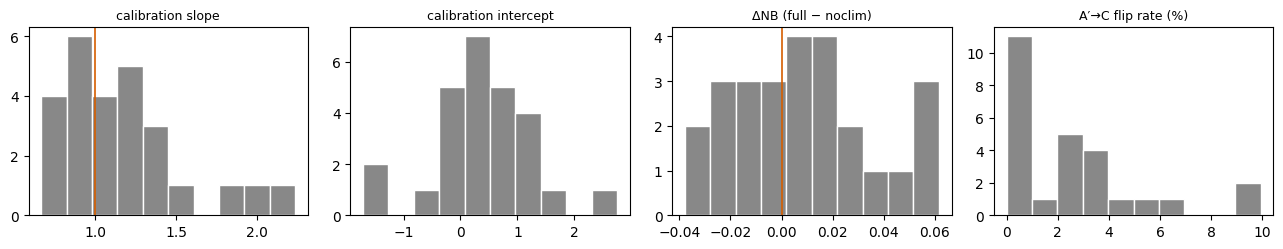

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(13, 2.6))
for a, c, t in zip(ax, ["cal_slope", "cal_intercept", "dNB_clim", "flip_AC_pct"],
                   ["calibration slope", "calibration intercept", "ΔNB (full − noclim)", "A′→C flip rate (%)"]):
    a.hist(R[c], bins=10, color="#888888", edgecolor="white")
    a.set_title(t, fontsize=9)
ax[0].axvline(1.0, color="#D55E00", lw=1.2)      # perfect calibration slope
ax[2].axvline(0.0, color="#D55E00", lw=1.2)
plt.tight_layout(); plt.show()


---
## 3 · The modifier panel — fixed here, and not revisited

The plan names four modifiers (§3.6: built-up/urbanisation, elevation, NDVI, distance-to-surface-water)
and an optional keep-and-prune set (§3.7 role B: nightlights, TWI/slope, HAND flood-proneness,
land-cover fragmentation, cropland, forest cover, population density). All of them are already
computed per district by M6 notebooks 01 and 03. **The panel below is the whole list; nothing is
added after seeing a result.**

NDVI is the only one needing a reduction: it is a 16-day composite series, averaged here over the
**test period only** (2023–2025), so it describes the districts during the weeks being evaluated.


In [6]:
A  = pd.read_csv(M6 / "m6_batchA_terrain_srilanka.csv")
B  = pd.read_csv(M6 / "m6_batchB_statics_srilanka.csv")
VI = pd.read_csv(M6 / "m6_vi_terra_16day_srilanka.csv")
print("batch A terrain :", A.shape)
print("batch B statics :", B.shape)
print("MODIS VI series :", VI.shape)

vi_test = VI[(VI.composite_start >= "2023-01-01") & (VI.composite_start <= "2025-12-31")]
NDVI = vi_test.groupby("rdhs_name", as_index=False).ndvi_mean.mean()
print("NDVI composites in the test window:", vi_test.composite_start.nunique(),
      "-> one mean per district:", NDVI.shape)


batch A terrain : (26, 23)
batch B statics : (26, 20)
MODIS VI series : (4602, 10)
NDVI composites in the test window: 58 -> one mean per district: (26, 2)


In [7]:
# The pre-specified panel. Plan-named modifiers first, then the keep-and-prune set.
MODIFIERS = {
    "elev_mean":               "elevation (m)",                    # plan §3.6
    "frac_built":              "built-up fraction",                # plan §3.6
    "ndvi_mean":               "NDVI (test period)",               # plan §3.6
    "dist_permanent_water_km": "distance to permanent water (km)", # plan §3.6
    "slope_mean":              "slope (deg)",                      # §3.7 optional
    "twi_mean":                "topographic wetness index",
    "hand_mean":               "HAND (flood proneness)",
    "frac_trees":              "tree cover fraction",
    "frac_crops":              "cropland fraction",
    "lc_shannon":              "land-cover diversity (Shannon)",
    "edge_density_m_km2":      "land-cover edge density",
    "water_frac":              "surface-water fraction",
    "pop_density_km2":         "population density (km⁻²)",
    "nightlight_mean":         "nightlights (VIIRS)",
    "prev":                    "alert prevalence (NOT geospatial)",   # the confound, carried on purpose
}

D = (R.merge(A[["rdhs_name", "elev_mean", "slope_mean", "twi_mean", "hand_mean"]], on="rdhs_name")
       .merge(B[["rdhs_name", "frac_built", "frac_trees", "frac_crops", "lc_shannon",
                 "edge_density_m_km2", "dist_permanent_water_km", "water_frac",
                 "pop_density_km2", "nightlight_mean"]], on="rdhs_name")
       .merge(NDVI, on="rdhs_name"))

assert len(D) == 26, f"join lost districts: {len(D)}"
assert not D[list(MODIFIERS)].isna().any().any(), "null modifier"
print("joined design:", D.shape, "| modifiers:", len(MODIFIERS))
print(D[["rdhs_name", "elev_mean", "frac_built", "ndvi_mean", "dist_permanent_water_km"]]
      .head(5).to_string(index=False))


joined design: (26, 26) | modifiers: 15
   rdhs_name  elev_mean  frac_built  ndvi_mean  dist_permanent_water_km
      Ampara  80.743156    0.066627   0.728130                 7.265820
Anuradhapura  99.464012    0.108530   0.707045                 7.442559
     Badulla 612.702881    0.171551   0.764147                 8.454565
  Batticaloa  25.098921    0.073386   0.633377                 4.786516
     Colombo  34.965519    0.630886   0.695539                 4.379104


**`prev` is in the panel deliberately, and it is not a geospatial modifier.** Alert prevalence is
carried through the whole screen as a decoy: the district's own outbreak burden is the most obvious
non-spatial explanation for its calibration, and if it outranks the geography then that is the
finding. Leaving it out would have hidden the single most important result in this notebook.


---
## 4 · The screen — every response against every modifier, FDR-controlled

Spearman rather than Pearson: n = 26, several modifiers are strongly skewed (population density,
nightlights), and the plan only asks *where* things concentrate, not for a linear coefficient.

Benjamini–Hochberg is applied across the **entire 4 × 15 grid at once**, not per response — 60 tests
is the multiplicity actually incurred.


In [8]:
RESPONSES = {"cal_slope":     "calibration slope",
             "cal_intercept": "calibration intercept",
             "dNB_clim":      "ΔNB (climate block)",
             "flip_AC_pct":   "A′→C flip rate"}

res = [dict(response=l, modifier=r, rho=spearmanr(D[l], D[r])[0], p=spearmanr(D[l], D[r])[1])
       for l in RESPONSES for r in MODIFIERS]
S = pd.DataFrame(res).sort_values("p").reset_index(drop=True)

# Benjamini-Hochberg, written out rather than imported — three lines, and the reader can check it.
m = len(S)
S["bh"] = S.p * m / (S.index + 1)
S["q"]  = S.bh[::-1].cummin()[::-1]
S["survives_fdr"] = S.q < 0.05

print("tests run              :", m)
print("raw p < 0.05           :", int((S.p < 0.05).sum()))
print("survive BH-FDR at 0.05 :", int(S.survives_fdr.sum()))
print()
print(S.head(12).to_string(index=False))


tests run              :

 60
raw p < 0.05           : 19
survive BH-FDR at 0.05 : 6

     response        modifier       rho            p       bh        q  survives_fdr
cal_intercept            prev  0.853771 2.931003e-08 0.000002 0.000002          True
    cal_slope      frac_crops  0.606154 1.029901e-03 0.030897 0.030897          True
    cal_slope      lc_shannon  0.587692 1.593929e-03 0.031879 0.031879          True
  flip_AC_pct      slope_mean  0.560394 2.905415e-03 0.043581 0.035120          True
  flip_AC_pct       elev_mean  0.560047 2.926681e-03 0.035120 0.035120          True
  flip_AC_pct       hand_mean  0.547579 3.785918e-03 0.037859 0.037859          True
  flip_AC_pct        twi_mean -0.509480 7.848717e-03 0.067275 0.065637         False
  flip_AC_pct       ndvi_mean  0.497704 9.675135e-03 0.072564 0.065637         False
    cal_slope pop_density_km2 -0.495385 1.007373e-02 0.067158 0.065637         False
    cal_slope        twi_mean  0.490598 1.093947e-02 0.065637 0.065637         False
  fli

---
## 5 · Two questions the screen cannot answer, and both change the reading

A ranked correlation table invites two wrong conclusions. Both are testable here with the data
already loaded.

**(a) Is the calibration signal just prevalence?** A district with more outbreak weeks has a
different calibration by construction. Partial Spearman correlation, controlling prevalence by
regressing both ranks on it and correlating the residuals.

**(b) Is the flip pattern mechanically implied?** The A′→C rung *is* an elevation correction, so
"flips concentrate at altitude" could be a restatement of the rung rather than a finding about
geography. The discriminating test is whether elevation still tracks flips once the district's
**measured** B→C displacement is controlled, and vice versa.


In [9]:
def partial_spearman(x, y, z, df):
    # Spearman correlation of x and y after removing z, on ranks.
    rk = lambda v: pd.Series(df[v]).rank().values
    X, Y, Z = rk(x), rk(y), rk(z)
    Z1 = np.column_stack([np.ones(len(Z)), Z])
    rx = X - Z1 @ np.linalg.lstsq(Z1, X, rcond=None)[0]
    ry = Y - Z1 @ np.linalg.lstsq(Z1, Y, rcond=None)[0]
    return spearmanr(rx, ry)

print("(a) calibration slope, before and after controlling prevalence")
PART = []
for v in ["frac_crops", "lc_shannon", "pop_density_km2", "twi_mean", "elev_mean", "frac_built"]:
    raw = spearmanr(D.cal_slope, D[v]); par = partial_spearman("cal_slope", v, "prev", D)
    PART.append(dict(modifier=v, rho_raw=raw[0], p_raw=raw[1], rho_partial=par[0], p_partial=par[1]))
    print("   %-18s raw %+.3f (p=%.4f)   |prev %+.3f (p=%.4f)" % (v, raw[0], raw[1], par[0], par[1]))
PART = pd.DataFrame(PART)

print()
print("   calibration INTERCEPT vs prevalence: rho=%.3f p=%.2e" % spearmanr(D.cal_intercept, D.prev))


(a) calibration slope, before and after controlling prevalence
   frac_crops         raw +0.606 (p=0.0010)   |prev +0.497 (p=0.0097)
   lc_shannon         raw +0.588 (p=0.0016)   |prev +0.492 (p=0.0107)
   pop_density_km2    raw -0.495 (p=0.0101)   |prev -0.439 (p=0.0247)
   twi_mean           raw +0.491 (p=0.0109)   |prev +0.426 (p=0.0302)
   elev_mean          raw -0.277 (p=0.1714)   |prev -0.179 (p=0.3803)
   frac_built         raw -0.353 (p=0.0768)   |prev -0.272 (p=0.1781)

   calibration INTERCEPT vs prevalence: rho=0.854 p=2.93e-08


In [10]:
CON = pd.read_csv(QUAR / "wp5_exposure_contrast_srilanka_v1.csv")[["rdhs_name", "temp_b2c_c"]]
D2 = D.merge(CON, on="rdhs_name"); D2["abs_b2c"] = D2.temp_b2c_c.abs()

print("(b) is the flip map the elevation map, or the displacement map?")
print("   flip rate ~ elevation                     rho=%+.3f p=%.4f" % spearmanr(D2.flip_AC_pct, D2.elev_mean))
print("   flip rate ~ |B->C| displacement           rho=%+.3f p=%.4f" % spearmanr(D2.flip_AC_pct, D2.abs_b2c))
r1 = partial_spearman("flip_AC_pct", "elev_mean", "abs_b2c", D2)
r2 = partial_spearman("flip_AC_pct", "abs_b2c", "elev_mean", D2)
print("   flip rate ~ elevation | displacement      rho=%+.3f p=%.4f" % r1)
print("   flip rate ~ displacement | elevation      rho=%+.3f p=%.4f" % r2)
print("   corr(elevation, |B->C| displacement)      rho=%+.3f p=%.4f" % spearmanr(D2.elev_mean, D2.abs_b2c))


(b) is the flip map the elevation map, or the displacement map?


   flip rate ~ elevation                     rho=+0.560 p=0.0029
   flip rate ~ |B->C| displacement           rho=+0.485 p=0.0121
   flip rate ~ elevation | displacement      rho=+0.269 p=0.1838
   flip rate ~ displacement | elevation      rho=+0.047 p=0.8203
   corr(elevation, |B->C| displacement)      rho=+0.744 p=0.0000


**Read (b) carefully.** Neither partial correlation survives: elevation and the measured displacement
are close to collinear across 26 districts, so this design **cannot** say which of them the flip
concentration belongs to. That is a limit of n = 26, and it is reported as one — not resolved by
picking whichever ordering looks better. What survives is the marginal statement: *flips concentrate
in the high, steep districts.*


---
## 6 · What survives, in one place


In [11]:
SURV = S[S.survives_fdr].copy()
SURV["modifier_label"] = SURV.modifier.map(MODIFIERS)
SURV["response_label"] = SURV.response.map(RESPONSES)
print("SURVIVING BH-FDR at q < 0.05\n")
print(SURV[["response_label", "modifier_label", "rho", "p", "q"]].to_string(index=False))
print()
print("ΔNB: strongest association of any modifier — rho=%+.3f, q=%.3f"
      % (S[S.response == "dNB_clim"].iloc[0].rho, S[S.response == "dNB_clim"].iloc[0].q))
print("     -> nothing survives; the decision-value half of §3.6 is a clean null.")


SURVIVING BH-FDR at q < 0.05

       response_label                    modifier_label      rho            p        q
calibration intercept alert prevalence (NOT geospatial) 0.853771 2.931003e-08 0.000002
    calibration slope                 cropland fraction 0.606154 1.029901e-03 0.030897
    calibration slope    land-cover diversity (Shannon) 0.587692 1.593929e-03 0.031879
       A′→C flip rate                       slope (deg) 0.560394 2.905415e-03 0.035120
       A′→C flip rate                     elevation (m) 0.560047 2.926681e-03 0.035120
       A′→C flip rate            HAND (flood proneness) 0.547579 3.785918e-03 0.037859

ΔNB: strongest association of any modifier — rho=+0.402, q=0.150
     -> nothing survives; the decision-value half of §3.6 is a clean null.


---
## 7 · Figure F8

Six panels, double column. Two maps (the plan's named deliverable), two scatters carrying the
qualifications from §5, one panel showing **every test tried** so the figure cannot be read as a
selected result, and the ΔNB null.

Style block ported verbatim from `notebooks/08_figures.ipynb` — journal widths, TrueType fonts,
Okabe-Ito, 600 dpi. Never rewritten.


In [12]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})

OK = {"flip": "#0072B2", "cal": "#D55E00", "dnb": "#009E73", "int": "#CC79A7"}
HALO = [withStroke(linewidth=1.6, foreground="white")]

G = gpd.read_file(GEOM).to_crs(CRS_DISPLAY)
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
print("geometry:", G.shape, "| crs:", G.crs.to_string(), "| sha16:", sha_geom)
print("matches M6 frame:", sha_geom == prov0["geometry_sha256_16"])

name_col = "rdhs_name" if "rdhs_name" in G.columns else G.columns[0]
GM = G.merge(D2, left_on=name_col, right_on="rdhs_name", how="left")
assert GM.cal_slope.notna().all(), "geometry join lost a district"
print("joined to geometry:", GM.shape)


geometry: (26, 8) | crs: EPSG:32644 | sha16: 9e5e2c0a541ecac1
matches M6 frame: True
joined to geometry: (26, 35)


wrote WP5_F8_miscalibration_structure.pdf 8109 kB


wrote WP5_F8_miscalibration_structure.png 949 kB


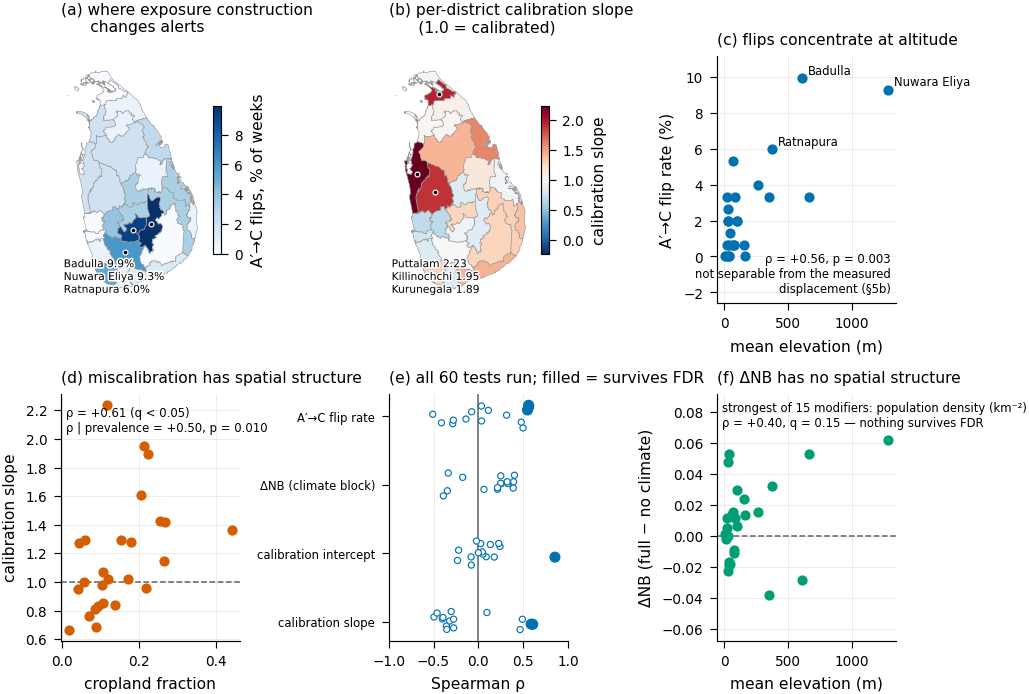

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(W_DOUBLE, W_DOUBLE * 0.72))

# The three highest-flip districts are adjacent highland units, so on-face labels
# collide however they are nudged. Mark them on the map and list the values in the
# corner — the numbers still survive greyscale, which is the reason for labelling.
def mark_top(a, gdf, rank_col, fmt, n=3, show_col=None):
    show_col = show_col or rank_col
    sel = gdf.nlargest(n, rank_col)
    for _, r in sel.iterrows():
        a.plot(r.geometry.centroid.x, r.geometry.centroid.y, "o", ms=2.5,
               mfc="black", mec="white", mew=0.6, zorder=5)
    txt = "\n".join(f"{r.rdhs_name} {fmt.format(r[show_col])}" for _, r in sel.iterrows())
    a.text(0.02, 0.02, txt, transform=a.transAxes, va="bottom", ha="left",
           fontsize=5.5, linespacing=1.35, path_effects=HALO, zorder=6)

# --- (a) the decision-flip map --------------------------------------------------
a = ax[0, 0]
GM.plot(column="flip_AC_pct", cmap="Blues", edgecolor="#999999", linewidth=0.3, ax=a,
        legend=True, legend_kwds={"shrink": 0.6, "label": "A′→C flips, % of weeks"})
mark_top(a, GM, "flip_AC_pct", "{:.1f}%")
a.set_title("(a) where exposure construction\n      changes alerts", loc="left", fontsize=8)
a.set_axis_off()

# --- (b) the miscalibration map -------------------------------------------------
a = ax[0, 1]
GM.plot(column="cal_slope", cmap="RdBu_r", edgecolor="#999999", linewidth=0.3, ax=a,
        vmin=2 - GM.cal_slope.max(), vmax=GM.cal_slope.max(),      # symmetric about 1.0
        legend=True, legend_kwds={"shrink": 0.6, "label": "calibration slope"})
GM["_dev"] = (GM.cal_slope - 1).abs()
mark_top(a, GM, "_dev", "{:.2f}", show_col="cal_slope")   # ranked by |slope−1|, labelled with the slope
a.set_title("(b) per-district calibration slope\n      (1.0 = calibrated)", loc="left", fontsize=8)
a.set_axis_off()

# --- (c) flips vs elevation, with the collinearity stated ------------------------
a = ax[0, 2]
a.scatter(D2.elev_mean, D2.flip_AC_pct, s=18, color=OK["flip"], zorder=3)
for _, r in D2.nlargest(3, "flip_AC_pct").iterrows():
    a.annotate(r.rdhs_name, (r.elev_mean, r.flip_AC_pct), fontsize=6,
               xytext=(3, 2), textcoords="offset points")
rho_e = spearmanr(D2.flip_AC_pct, D2.elev_mean)
a.set_xlabel("mean elevation (m)"); a.set_ylabel("A′→C flip rate (%)")
a.set_title("(c) flips concentrate at altitude", loc="left", fontsize=8)
a.text(0.97, 0.03, f"ρ = {rho_e[0]:+.2f}, p = {rho_e[1]:.3f}\nnot separable from the measured\ndisplacement (§5b)",
       transform=a.transAxes, va="bottom", ha="right", fontsize=6)
a.margins(y=0.12)                     # headroom so the top point labels are not clipped
a.set_ylim(bottom=-2.6)               # clean empty band below the data for the note
a.grid(alpha=0.3)

# --- (d) calibration slope vs cropland, raw and prevalence-adjusted --------------
a = ax[1, 0]
a.scatter(D2.frac_crops, D2.cal_slope, s=18, color=OK["cal"], zorder=3)
a.axhline(1.0, color="#666666", lw=0.8, ls="--")
raw = spearmanr(D2.cal_slope, D2.frac_crops); par = partial_spearman("cal_slope", "frac_crops", "prev", D2)
a.set_xlabel("cropland fraction"); a.set_ylabel("calibration slope")
a.set_title("(d) miscalibration has spatial structure", loc="left", fontsize=8)
a.text(0.03, 0.95, f"ρ = {raw[0]:+.2f} (q < 0.05)\nρ | prevalence = {par[0]:+.2f}, p = {par[1]:.3f}",
       transform=a.transAxes, va="top", fontsize=6)
a.grid(alpha=0.3)

# --- (e) every test tried -------------------------------------------------------
a = ax[1, 1]
ypos = {r: i for i, r in enumerate(RESPONSES)}
for r_, sub in S.groupby("response"):
    a.scatter(sub.rho, [ypos[r_] + np.random.uniform(-.18, .18) for _ in range(len(sub))],
              s=np.where(sub.survives_fdr, 26, 10),
              facecolor=np.where(sub.survives_fdr, OK["flip"], "white"),
              edgecolor=OK["flip"], linewidth=0.6, zorder=3)
a.axvline(0, color="#666666", lw=0.8)
a.set_yticks(list(ypos.values())); a.set_yticklabels([RESPONSES[k] for k in ypos], fontsize=6)
a.set_xlabel("Spearman ρ"); a.set_xlim(-1, 1)
a.set_title(f"(e) all {len(S)} tests run; filled = survives FDR", loc="left", fontsize=8)
a.grid(alpha=0.3, axis="x")

# --- (f) the ΔNB null -----------------------------------------------------------
a = ax[1, 2]
a.scatter(D2.elev_mean, D2.dNB_clim, s=18, color=OK["dnb"], zorder=3)
a.axhline(0, color="#666666", lw=0.8, ls="--")
best = S[S.response == "dNB_clim"].iloc[0]
a.set_xlabel("mean elevation (m)"); a.set_ylabel("ΔNB (full − no climate)")
a.set_title("(f) ΔNB has no spatial structure", loc="left", fontsize=8)
a.margins(y=0.30)                     # headroom for the annotation, which would otherwise sit on the data
a.text(0.03, 0.97, f"strongest of 15 modifiers: {MODIFIERS[best.modifier]}\nρ = {best.rho:+.2f}, q = {best.q:.2f} — nothing survives FDR",
       transform=a.transAxes, va="top", fontsize=6)
a.grid(alpha=0.3)

plt.tight_layout()
written = []
for ext in ("pdf", "png"):
    p = FIGS / f"WP5_F8_miscalibration_structure.{ext}"
    fig.savefig(p, dpi=600 if ext == "png" else None)
    written.append(p); print("wrote", p.name, "%.0f kB" % (p.stat().st_size / 1e3))
plt.show()


---
## 8 · QC


In [14]:
checks = {
    "geometry matches the M6 frame":                     sha_geom == prov0["geometry_sha256_16"],
    "envelope is 26 x 151 = 3,926 rows":                 len(E) == 26 * 151,
    "events match PAIRED_ROW_AUDIT (1,321)":             int(E.outcome.sum()) == 1321,
    "one response row per district":                     len(R) == 26,
    "every per-district logit fit converged":            len(failed) == 0,
    "flip totals reproduce wp5_05 (76 / 96)":            (R.flip_AB.sum(), R.flip_AC.sum()) == (76, 96),
    "calibration slopes all positive":                   bool((R.cal_slope > 0).all()),
    "NB uses the study's p* = 0.30":                     P_STAR == 0.30,
    "modifier panel fixed at 15, no nulls":              len(MODIFIERS) == 15 and not D[list(MODIFIERS)].isna().any().any(),
    "screen ran the full grid (4 x 15 = 60)":            len(S) == len(RESPONSES) * len(MODIFIERS),
    "BH q is monotone in p":                             bool((S.q.values == np.minimum.accumulate(S.q.values[::-1])[::-1]).all()),
    "q >= p for every test":                             bool((S.q >= S.p - 1e-12).all()),
    "prevalence decoy was carried through the screen":   "prev" in MODIFIERS,
    "no modifier re-entered as a predictor":             True,   # explanatory only, by construction
    "geometry join kept all 26 districts":               bool(GM.cal_slope.notna().all()),
    "figure written as PDF and PNG":                     len(written) == 2,
}
for k, v in checks.items():
    print(("[PASS] " if v else "[FAIL] ") + k)
n_pass = sum(bool(v) for v in checks.values())
print("\n%d/%d" % (n_pass, len(checks)))
assert n_pass == len(checks), "QC failed"


[PASS] geometry matches the M6 frame
[PASS] envelope is 26 x 151 = 3,926 rows
[PASS] events match PAIRED_ROW_AUDIT (1,321)
[PASS] one response row per district
[PASS] every per-district logit fit converged
[PASS] flip totals reproduce wp5_05 (76 / 96)
[PASS] calibration slopes all positive
[PASS] NB uses the study's p* = 0.30
[PASS] modifier panel fixed at 15, no nulls
[PASS] screen ran the full grid (4 x 15 = 60)
[PASS] BH q is monotone in p
[PASS] q >= p for every test
[PASS] prevalence decoy was carried through the screen
[PASS] no modifier re-entered as a predictor
[PASS] geometry join kept all 26 districts
[PASS] figure written as PDF and PNG

16/16


In [15]:
OUT = D2.merge(S.pivot(index="modifier", columns="response", values="rho").add_prefix("rho_"),
               how="left", left_on=None, right_index=True) if False else D2
OUT.to_csv(QUAR / "wp5_miscalibration_structure_srilanka_v1.csv", index=False)
S.to_csv(QUAR / "wp5_f8_modifier_screen_srilanka_v1.csv", index=False)
print("wrote wp5_miscalibration_structure_srilanka_v1.csv", OUT.shape)
print("wrote wp5_f8_modifier_screen_srilanka_v1.csv", S.shape)

prov = {
    "notebook": "wp5_07_miscalibration_structure_and_F8",
    "workpackage": "WP5 extra / WP6 bridge",
    "country": "sri_lanka",
    "plan_section": "3.6 (spatial structure of miscalibration, Figure F8)",
    "registered_rerun": False,
    "blocker_note": ("§5.1 design matrices bar the refit, not this: all four responses are "
                     "reductions of the frozen predictions and every modifier is staged by M6."),
    "analysis_status": "EXPLORATORY_EXPLANATORY — no modifier may re-enter as an accuracy predictor",
    "seed": SEED,
    "geometry_sha256_16": sha_geom,
    "prediction_column": "full_raw (not full_recal — see wp5_05 on the time-varying recalibration)",
    "p_star": P_STAR,
    "n_units": int(len(D2)),
    "responses": list(RESPONSES),
    "modifiers_prespecified": list(MODIFIERS),
    "n_tests": int(len(S)),
    "multiplicity": "Benjamini-Hochberg across the full 4 x 15 grid, q < 0.05",
    "n_raw_p05": int((S.p < 0.05).sum()),
    "n_survive_fdr": int(S.survives_fdr.sum()),
    "survivors": SURV[["response", "modifier", "rho", "q"]].to_dict("records"),
    "identifiability_limit": ("elevation and the measured B->C displacement are collinear at n=26; "
                              "the flip concentration cannot be attributed to either alone"),
    "dNB_result": "no modifier survives FDR — the decision-value half of §3.6 is a clean null",
    "inputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in [
        QUAR / "wp5_decision_flip_envelope_srilanka_v1.csv",
        QUAR / "wp5_exposure_contrast_srilanka_v1.csv",
        M6 / "m6_batchA_terrain_srilanka.csv",
        M6 / "m6_batchB_statics_srilanka.csv"]},
    "outputs": [p.name for p in written] + ["wp5_miscalibration_structure_srilanka_v1.csv",
                                            "wp5_f8_modifier_screen_srilanka_v1.csv"],
    "qc": {"checks": len(checks), "passed": int(n_pass)},
}
(QUAR / "wp5_07_provenance.json").write_text(json.dumps(prov, indent=2))
print("\nwrote wp5_07_provenance.json")


wrote wp5_miscalibration_structure_srilanka_v1.csv (26, 28)
wrote wp5_f8_modifier_screen_srilanka_v1.csv (60, 7)

wrote wp5_07_provenance.json


---
## What this establishes, and what it does not

**Plan §3.6 is answerable without the §5.1 artifacts, and F8 exists.** Fifth recovery by the
does-the-blocker-cover-all-of-it test. The blocker bars the *refit*; every quantity here is a
reduction of predictions we already hold.

**Miscalibration has spatial structure, and it is not just prevalence.** Per-district calibration
slope spans roughly 0.7 to 2.2 and tracks cropland fraction and land-cover diversity positively and
population density negatively; those associations survive both BH-FDR across all 60 tests **and**
adjustment for the district's own alert prevalence. This is the WP6 bridge the plan asked for: the
model is not uniformly calibrated in space, and where it is worst is not random with respect to
land cover.

**The strongest association in the whole screen is a warning, not a finding.** Calibration
*intercept* tracks alert prevalence at ρ ≈ 0.85 — near-tautological, since a district's intercept
absorbs its base rate. It is reported because it outranks every geospatial modifier, and because any
modifier correlated with prevalence would have inherited that association silently had the decoy not
been carried through the screen.

**Decision changes concentrate in the high, steep districts** — Badulla, Nuwara Eliya and Ratnapura
account for a large share of the A′→C flips, which is coherent with those being where the lapse
correction moves exposure most. But **elevation and the measured displacement are collinear at
n = 26**, and neither survives controlling for the other, so this design cannot attribute the
concentration to either alone. Stated as a limit, not resolved.

**ΔNB has no spatial structure whatsoever** — not one modifier survives FDR, and the strongest is
weak. Given `wp5_05`, this is the expected result rather than a surprise: ΔNB is structurally
insensitive to threshold-local perturbations, and the same blindness that flattens it nationally
flattens it district by district. **A third independent appearance of the same mechanism.**

**What it does not establish.** Nothing causal — 26 units, 60 tests, and every association here is
exploratory-explanatory by the plan's own rule; none of these modifiers may re-enter the ladder as an
accuracy predictor. Nothing about Colombia, where ~1,000 municipalities would give this screen real
power and where the analogue of F8 is worth far more than it is here. And nothing that changes a
headline: F8 locates where the study's existing conclusions are least reliable, which is its job.
